
# CIFAR-10 Regularisation — visual annotated learning notebook

This version is built from your latest `Regularisation(4).ipynb`.

The aim is not only to make the model run. It is to let you answer, by yourself:

1. **What enters each layer?**
2. **What comes out?**
3. **Which layers learn parameters and which do not?**
4. **How do accuracy, loss and validation tell me what is wrong?**
5. **Which parameter should I change next, and why?**
6. **How do I run a controlled experiment instead of randomly tuning everything?**

---

## First: what your latest recorded run actually says

Your latest notebook ran for **11 epochs**, although `epochs=50`.

Recorded values at the final logged epoch:

- training accuracy: **76.36%**
- validation accuracy: **75.73%**
- training loss: **0.6647**
- validation loss: **0.7084**
- lowest recorded validation loss: **0.6932 at epoch 10**

The train–validation accuracy gap at epoch 11 was only about **0.63 percentage points**, so the immediate problem was **not overfitting**.

The important problem was the `EarlyStopping` configuration:

```python
min_delta=0.2
patience=10
restore_best_weights=True
```

For a validation loss around `0.8`, `min_delta=0.2` is enormous.  
Although validation loss improved from **0.8105 → 0.6932**, that is only about **0.1173**, so `EarlyStopping` did **not** count it as a sufficiently large improvement.

Result:

- training stopped at epoch 11;
- the callback reported that it restored **epoch 1** weights;
- meanwhile `ModelCheckpoint` had correctly saved the actual lowest `val_loss` model from epoch 10.

So the notebook ended with two different ideas of “best model”. This version fixes that.


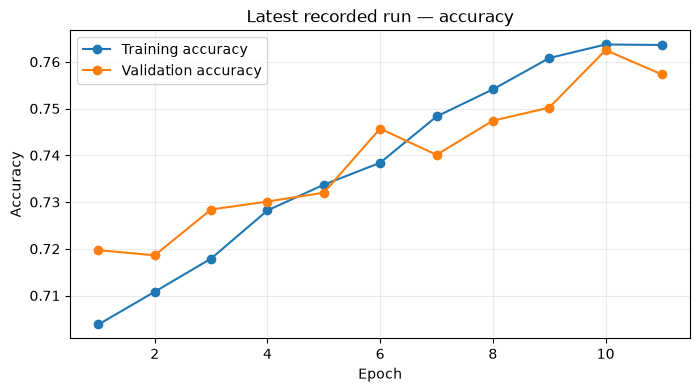

/home/bm/formation/deeplearning/deeplearning1/.venv/bin/python
pydot OK


In [1]:
# NumPy stores arrays and helps calculate statistics such as the best epoch.
import numpy as np

# Matplotlib creates images, diagrams and training curves.
import matplotlib.pyplot as plt

# This graph is reconstructed from the values saved in your latest notebook.
# It lets us diagnose the run even before retraining.

epochs = np.arange(1, 12)

train_acc_recorded = np.array([
    0.7038, 0.7108, 0.7179, 0.7282, 0.7337, 0.7384,
    0.7483, 0.7541, 0.7608, 0.7637, 0.7636
])

val_acc_recorded = np.array([
    0.7197, 0.7186, 0.7284, 0.7301, 0.7320, 0.7457,
    0.7401, 0.7474, 0.7502, 0.7625, 0.7573
])

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc_recorded, marker="o", label="Training accuracy")
plt.plot(epochs, val_acc_recorded, marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Latest recorded run — accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# HOW TO READ THIS:
# - Both curves rise: the model is learning.
# - They stay close: there is no large overfitting gap here.
# - Validation sometimes exceeds training because augmentation + Dropout
#   make the training task deliberately harder than validation.

import sys
print(sys.executable)

import pydot
print("pydot OK")


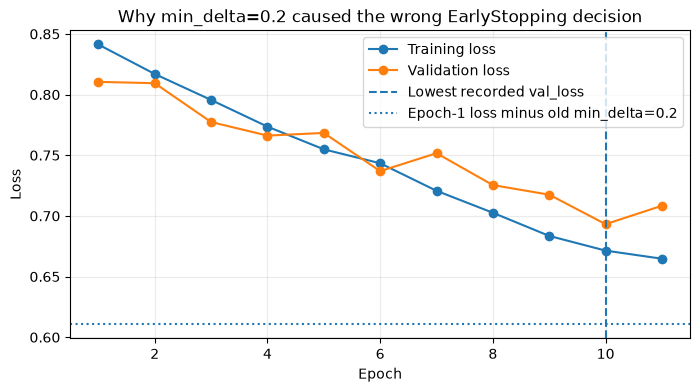

In [2]:
# Validation-loss history from your latest run.
train_loss_recorded = np.array([
    0.8413, 0.8170, 0.7956, 0.7736, 0.7549, 0.7434,
    0.7207, 0.7026, 0.6835, 0.6714, 0.6647
])

val_loss_recorded = np.array([
    0.8105, 0.8094, 0.7774, 0.7662, 0.7684, 0.7369,
    0.7517, 0.7254, 0.7175, 0.6932, 0.7084
])

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_recorded, marker="o", label="Training loss")
plt.plot(epochs, val_loss_recorded, marker="o", label="Validation loss")

# Epoch 10 was the lowest recorded validation loss.
plt.axvline(10, linestyle="--", label="Lowest recorded val_loss")

# With min_delta=0.2, EarlyStopping was waiting for an enormous improvement.
plt.axhline(
    val_loss_recorded[0] - 0.2,
    linestyle=":",
    label="Epoch-1 loss minus old min_delta=0.2"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Why min_delta=0.2 caused the wrong EarlyStopping decision")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# LEARNING POINT:
# Validation loss clearly improved.
# The callback setting was the problem — not the CNN itself.



# 1. Imports — what every tool is for

The imports below are grouped by job.  
I removed the idea that every imported tool must be used immediately. Some are kept as **future experiment tools**.


In [3]:
# ---------------------------
# ENVIRONMENT
# ---------------------------

# `os` lets Python set environment variables before Keras is imported.
import os

# Keras 3 can run on different backends.
# Your Digital City machine uses PyTorch successfully on the NVIDIA GPU,
# so we explicitly select the PyTorch backend.
#
# IMPORTANT: this must run BEFORE `import keras`.
os.environ["KERAS_BACKEND"] = "torch"


# ---------------------------
# NUMERICAL + VISUAL TOOLS
# ---------------------------



# Seaborn is useful later for statistical visualisations such as a confusion matrix.
import seaborn as sns


# ---------------------------
# KERAS MODEL TOOLS
# ---------------------------

# Keras is the high-level neural-network API.
import keras

# Sequential = layers are executed one after another.
# Model = useful later if we want to inspect intermediate layers.
from keras.models import Sequential, Model


# ---------------------------
# LAYERS USED IN THIS MODEL
# ---------------------------

from keras.layers import ( 
    Rescaling,
        Flatten,
        Dense,
        Conv2D,
        MaxPooling2D,
        Dropout,
        RandomFlip,
        RandomTranslation,
        RandomRotation,
        RandomZoom,
        RandomCrop,
        RandomContrast,
        RandomBrightness,
        RandomShear,
        RandomErasing,
        GlobalAveragePooling2D,
        AveragePooling2D,
        Concatenate,
        ReLU,
        Convolution2D,
        Input)


# ---------------------------
# OPTIMISATION + LOSS
# ---------------------------

# Adam uses gradients from backpropagation to update model weights.
from keras.optimizers import Adam

# Correct loss when labels are integers 0...9.
from keras.losses import SparseCategoricalCrossentropy


# ---------------------------
# TRAINING CONTROL
# ---------------------------

# EarlyStopping:
# stop training when validation performance stops improving.
#
# ModelCheckpoint:
# save the model that has the best monitored score.
#
# ReduceLROnPlateau:
# future experiment — reduce learning rate when progress stalls.
from keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
   
)


# ---------------------------
# DATA
# ---------------------------

# CIFAR-10 = 32×32 RGB images in 10 classes.
from keras.datasets import cifar10

# We create our validation set from the original training-side data.
from sklearn.model_selection import train_test_split

# Used later for class-by-class diagnostics.
from sklearn.metrics import classification_report, confusion_matrix

from  keras.utils import plot_model


# ---------------------------
# VERIFY THE SOFTWARE SETUP
# ---------------------------

print("Keras version:", keras.__version__)
print("Keras backend:", keras.backend.backend())


Keras version: 3.15.1
Keras backend: torch



# 2. Dataset — keep training, validation and test roles separate

Think of the three datasets as three different jobs:

- **Training**: the model is allowed to learn from these images.
- **Validation**: we use these images to make decisions about architecture and hyperparameters.
- **Test**: final independent examination. Do not repeatedly tune against it.


In [4]:
# Load CIFAR-10 exactly once.
# `_full` reminds us this is the complete original training-side dataset.
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Labels arrive as shape (N, 1), for example [[3], [7], [1]].
# `squeeze()` converts them to the simpler shape (N,), for example [3, 7, 1].
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# Split the 50,000 original training-side images:
# 80% -> 40,000 training
# 20% -> 10,000 validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,

    # 20% becomes validation.
    test_size=0.20,

    # Same random split every time -> experiments stay comparable.
    random_state=1,

    # Keep the 10 classes balanced in both subsets.
    stratify=y_train_full,
    
)

# Print the shapes so we can detect accidental data changes.
print("Train:     ", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:      ", x_test.shape, y_test.shape)

# Assertions stop the notebook if the split is not what we expect.
assert x_train.shape == (40000, 32, 32, 3)
assert x_val.shape == (10000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)

# CIFAR-10 raw pixels are integers from 0 to 255.
print("Pixel range:", x_train.min(), "to", x_train.max())
print("Data type:", x_train.dtype)


Train:      (40000, 32, 32, 3) (40000,)
Validation: (10000, 32, 32, 3) (10000,)
Test:       (10000, 32, 32, 3) (10000,)
Pixel range: 0 to 255
Data type: uint8


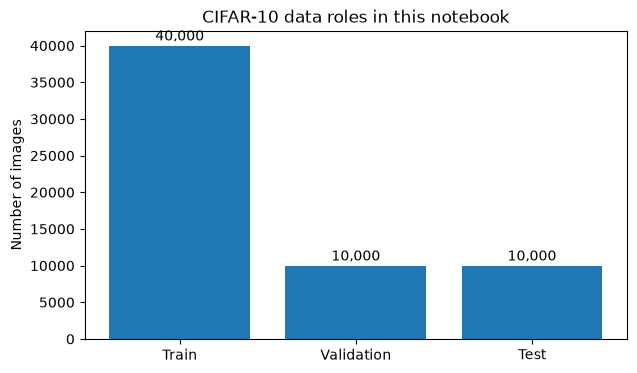

In [5]:
# Visualise the three dataset roles.
dataset_names = ["Train", "Validation", "Test"]
dataset_sizes = [40000, 10000, 10000]

plt.figure(figsize=(7, 4))
plt.bar(dataset_names, dataset_sizes)
plt.ylabel("Number of images")
plt.title("CIFAR-10 data roles in this notebook")

for i, size in enumerate(dataset_sizes):
    plt.text(i, size + 700, f"{size:,}", ha="center")

plt.show()



# 3. Data augmentation — make training harder on purpose

The goal is **not** to make prettier images.  
The goal is to make the model see plausible variations so it cannot memorize the training set too easily.

### Important correction about `RandomErasing`

In current Keras, `factor` controls the **probability of applying the transformation**.  
It is **not** the erased-area size.

Also, `RandomErasing` has a `value_range` argument. Because this model first rescales images to **0–1**, the erasing layer should explicitly know that its incoming range is `(0, 1)`.

This notebook therefore uses:

```python
RandomErasing(
    factor=(0.02, 0.33),
    value_range=(0, 1),
)
```

Interpretation:

> for each image, Keras samples an erasing probability between about 2% and 33%.

This keeps your present experiment concept close to what you already used, but makes the numerical range explicit.


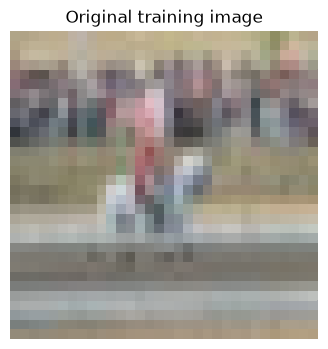

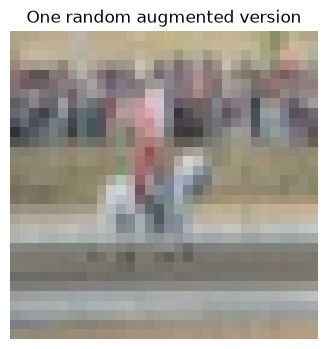

In [6]:
# A separate augmentation object is useful for VISUAL inspection.
# It does not train the CNN; it simply lets us see transformed examples.

data_augmenter = Sequential([
    # Mirror the image horizontally.
    RandomFlip("horizontal"),

    # Randomly erase some images.
    #
    # factor = probability of applying erasing.
    # value_range=(0, 1) because this demo explicitly rescales first.
    RandomErasing(
        factor=(0.02, 0.33),
        value_range=(0, 1),
    ),
])

# Pick one image.
sample_image = x_train[0:1]

# Scale it exactly as the model will.
sample_scaled = sample_image.astype("float32") / 255.0

# Apply random augmentation.
sample_augmented = data_augmenter(
    sample_scaled,
    training=True,
)

# With PyTorch backend, convert result to a NumPy array for Matplotlib.
sample_augmented = sample_augmented.cpu().numpy()


# Show ORIGINAL as its own figure.
plt.figure(figsize=(4, 4))
plt.imshow(sample_image[0])
plt.title("Original training image")
plt.axis("off")
plt.show()


# Show AUGMENTED as a separate figure.
plt.figure(figsize=(4, 4))
plt.imshow(np.clip(sample_augmented[0], 0, 1))
plt.title("One random augmented version")
plt.axis("off")
plt.show()

# EXPERIMENT:
# Run this cell several times.
# The same source image should receive different random transformations.



# 4. Model definition — follow both SHAPE and CAPACITY

Two different things happen through a CNN:

1. **Spatial size decreases**: 32 → 16 → 8 → 4.
2. **Feature depth increases**: 3 → 64 → 128 → 256.

A useful mental model is:

> less space, more learned feature channels.


In [7]:
# Build either the basic version or a regularized version.
def build_cnn_model(
    use_augmentation: bool = False,
    dropout_rate: float = 0.0,
) -> Sequential:

    # ---------------------------
    # A. INPUT + NUMERICAL SCALE
    # ---------------------------

    layers = [
        # ONE CIFAR image:
        # height=32, width=32, RGB channels=3.
        Input(shape=(32, 32, 3)),

        # 0–255 -> 0–1.
        # No trainable parameters.
        Rescaling(1.0 / 255),
    ]


    # ---------------------------
    # B. OPTIONAL AUGMENTATION
    # ---------------------------

    if use_augmentation:
        layers.extend([
            # No trainable parameters.
            # Used only during training.
            RandomFlip("horizontal"),

            # IMPORTANT:
            # `factor` controls probability, not erased-area size.
            #
            # We place RandomErasing AFTER Rescaling,
            # therefore its expected numerical range must be 0–1.
            RandomErasing(
                factor=(0.02, 0.33),
                value_range=(0, 1),
            ),

            # FUTURE CONTROLLED EXPERIMENTS:
            # enable ONE new tool at a time, then compare results.
            #
            # RandomTranslation(
            #     height_factor=0.10,
            #     width_factor=0.10,
            # ),
            #
            # RandomRotation(factor=0.05),
            #
            # RandomZoom(
            #     height_factor=0.10,
            #     width_factor=0.10,
            # ),
        ])


    # ---------------------------
    # C. FEATURE EXTRACTION
    # ---------------------------

    layers.extend([
        # INPUT: 32×32×3
        #
        # 64 different 3×3 filters.
        # OUTPUT: 32×32×64
        #
        # EXPERIMENT:
        # fewer filters -> lower capacity / faster
        # more filters  -> higher capacity / slower
        Conv2D(
            64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),

        # INPUT: 32×32×64
        # OUTPUT: 32×32×128
        Conv2D(
            128,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),

        # No trainable parameters.
        # 32×32×128 -> 16×16×128
        MaxPooling2D(pool_size=(2, 2)),

        # 16×16×128 -> 16×16×128
        Conv2D(
            128,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),

        # Same spatial size and channel count,
        # but another learned transformation.
        Conv2D(
            128,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),

        # 16×16×128 -> 8×8×128
        MaxPooling2D(pool_size=(2, 2)),

        # More feature channels near the end.
        # 8×8×128 -> 8×8×256
        Conv2D(
            256,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),

        # 8×8×256 -> 4×4×256
        MaxPooling2D(pool_size=(2, 2)),


        # ---------------------------
        # D. STRUCTURAL REGULARISATION
        # ---------------------------

        # 4×4×256 contains 4096 values.
        #
        # GlobalAveragePooling2D averages each 4×4 feature map.
        #
        # 4×4×256 -> 256 values
        #
        # This removes the large Flatten + Dense classification head
        # and dramatically reduces the number of parameters.
        GlobalAveragePooling2D(),

        # FUTURE CONTROLLED COMPARISON:
        #
        # Replace GAP with:
        #
        # Flatten(),
        # Dense(128, activation="relu"),
        #
        # Do NOT use both versions in the same comparison.
    ])


    # ---------------------------
    # E. OPTIONAL DROPOUT
    # ---------------------------

    if dropout_rate > 0:
        # dropout_rate=0.30 means:
        # during TRAINING, about 30% of these activations
        # are randomly set to zero on each step.
        #
        # This does NOT mean 30% of neurons are permanently deleted.
        layers.append(Dropout(dropout_rate))


    # ---------------------------
    # F. OUTPUT
    # ---------------------------

    # 10 neurons = 10 CIFAR-10 classes.
    # Softmax converts scores to class probabilities.
    layers.append(
        Dense(10, activation="softmax")
    )


    # Put all layers into one sequential model.
    model = Sequential(layers)


    # ---------------------------
    # G. TRAINING RULES
    # ---------------------------

    model.compile(
        # Adam controls weight updates.
        optimizer=Adam(),

        # Correct loss because labels are integer IDs 0...9.
        loss=SparseCategoricalCrossentropy(),

        # Accuracy = percentage of correct class predictions.
        metrics=["accuracy"],
    )

    return model


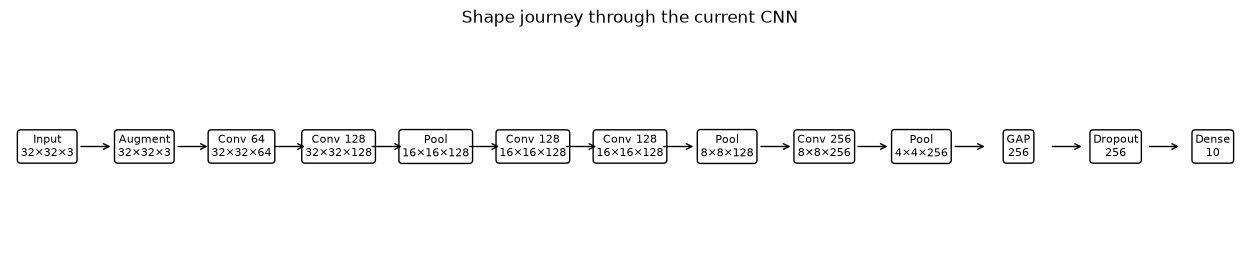

In [8]:
# Graphical map of the current model.
# This is useful when `model.summary()` feels too dense.

stage_names = [
    "Input\n32×32×3",
    "Augment\n32×32×3",
    "Conv 64\n32×32×64",
    "Conv 128\n32×32×128",
    "Pool\n16×16×128",
    "Conv 128\n16×16×128",
    "Conv 128\n16×16×128",
    "Pool\n8×8×128",
    "Conv 256\n8×8×256",
    "Pool\n4×4×256",
    "GAP\n256",
    "Dropout\n256",
    "Dense\n10",
]

plt.figure(figsize=(16, 3))
ax = plt.gca()
ax.axis("off")

x_positions = np.linspace(0.03, 0.97, len(stage_names))

for i, (x, label) in enumerate(zip(x_positions, stage_names)):
    ax.text(
        x,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.3",
            fill=False,
        ),
    )

    if i < len(stage_names) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1] - 0.025, 0.5),
            xytext=(x + 0.025, 0.5),
            arrowprops=dict(arrowstyle="->"),
        )

plt.title("Shape journey through the current CNN")
plt.show()


<bound method Layer.count_params of <Functional name=functional_17, built=True>>
Model summary:


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 32, 32, 3) │          0 │ input_layer_3[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │        416 │ rescaling_2[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     51,264 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │      2,112 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ conv2d_9[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 131072)    │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4000)      │ 524,292,0… │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │     40,010 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 524,385,802 (1.95 GB)

 Trainable params: 524,385,802 (1.95 GB)

 Non-trainable params: 0 (0.00 B)

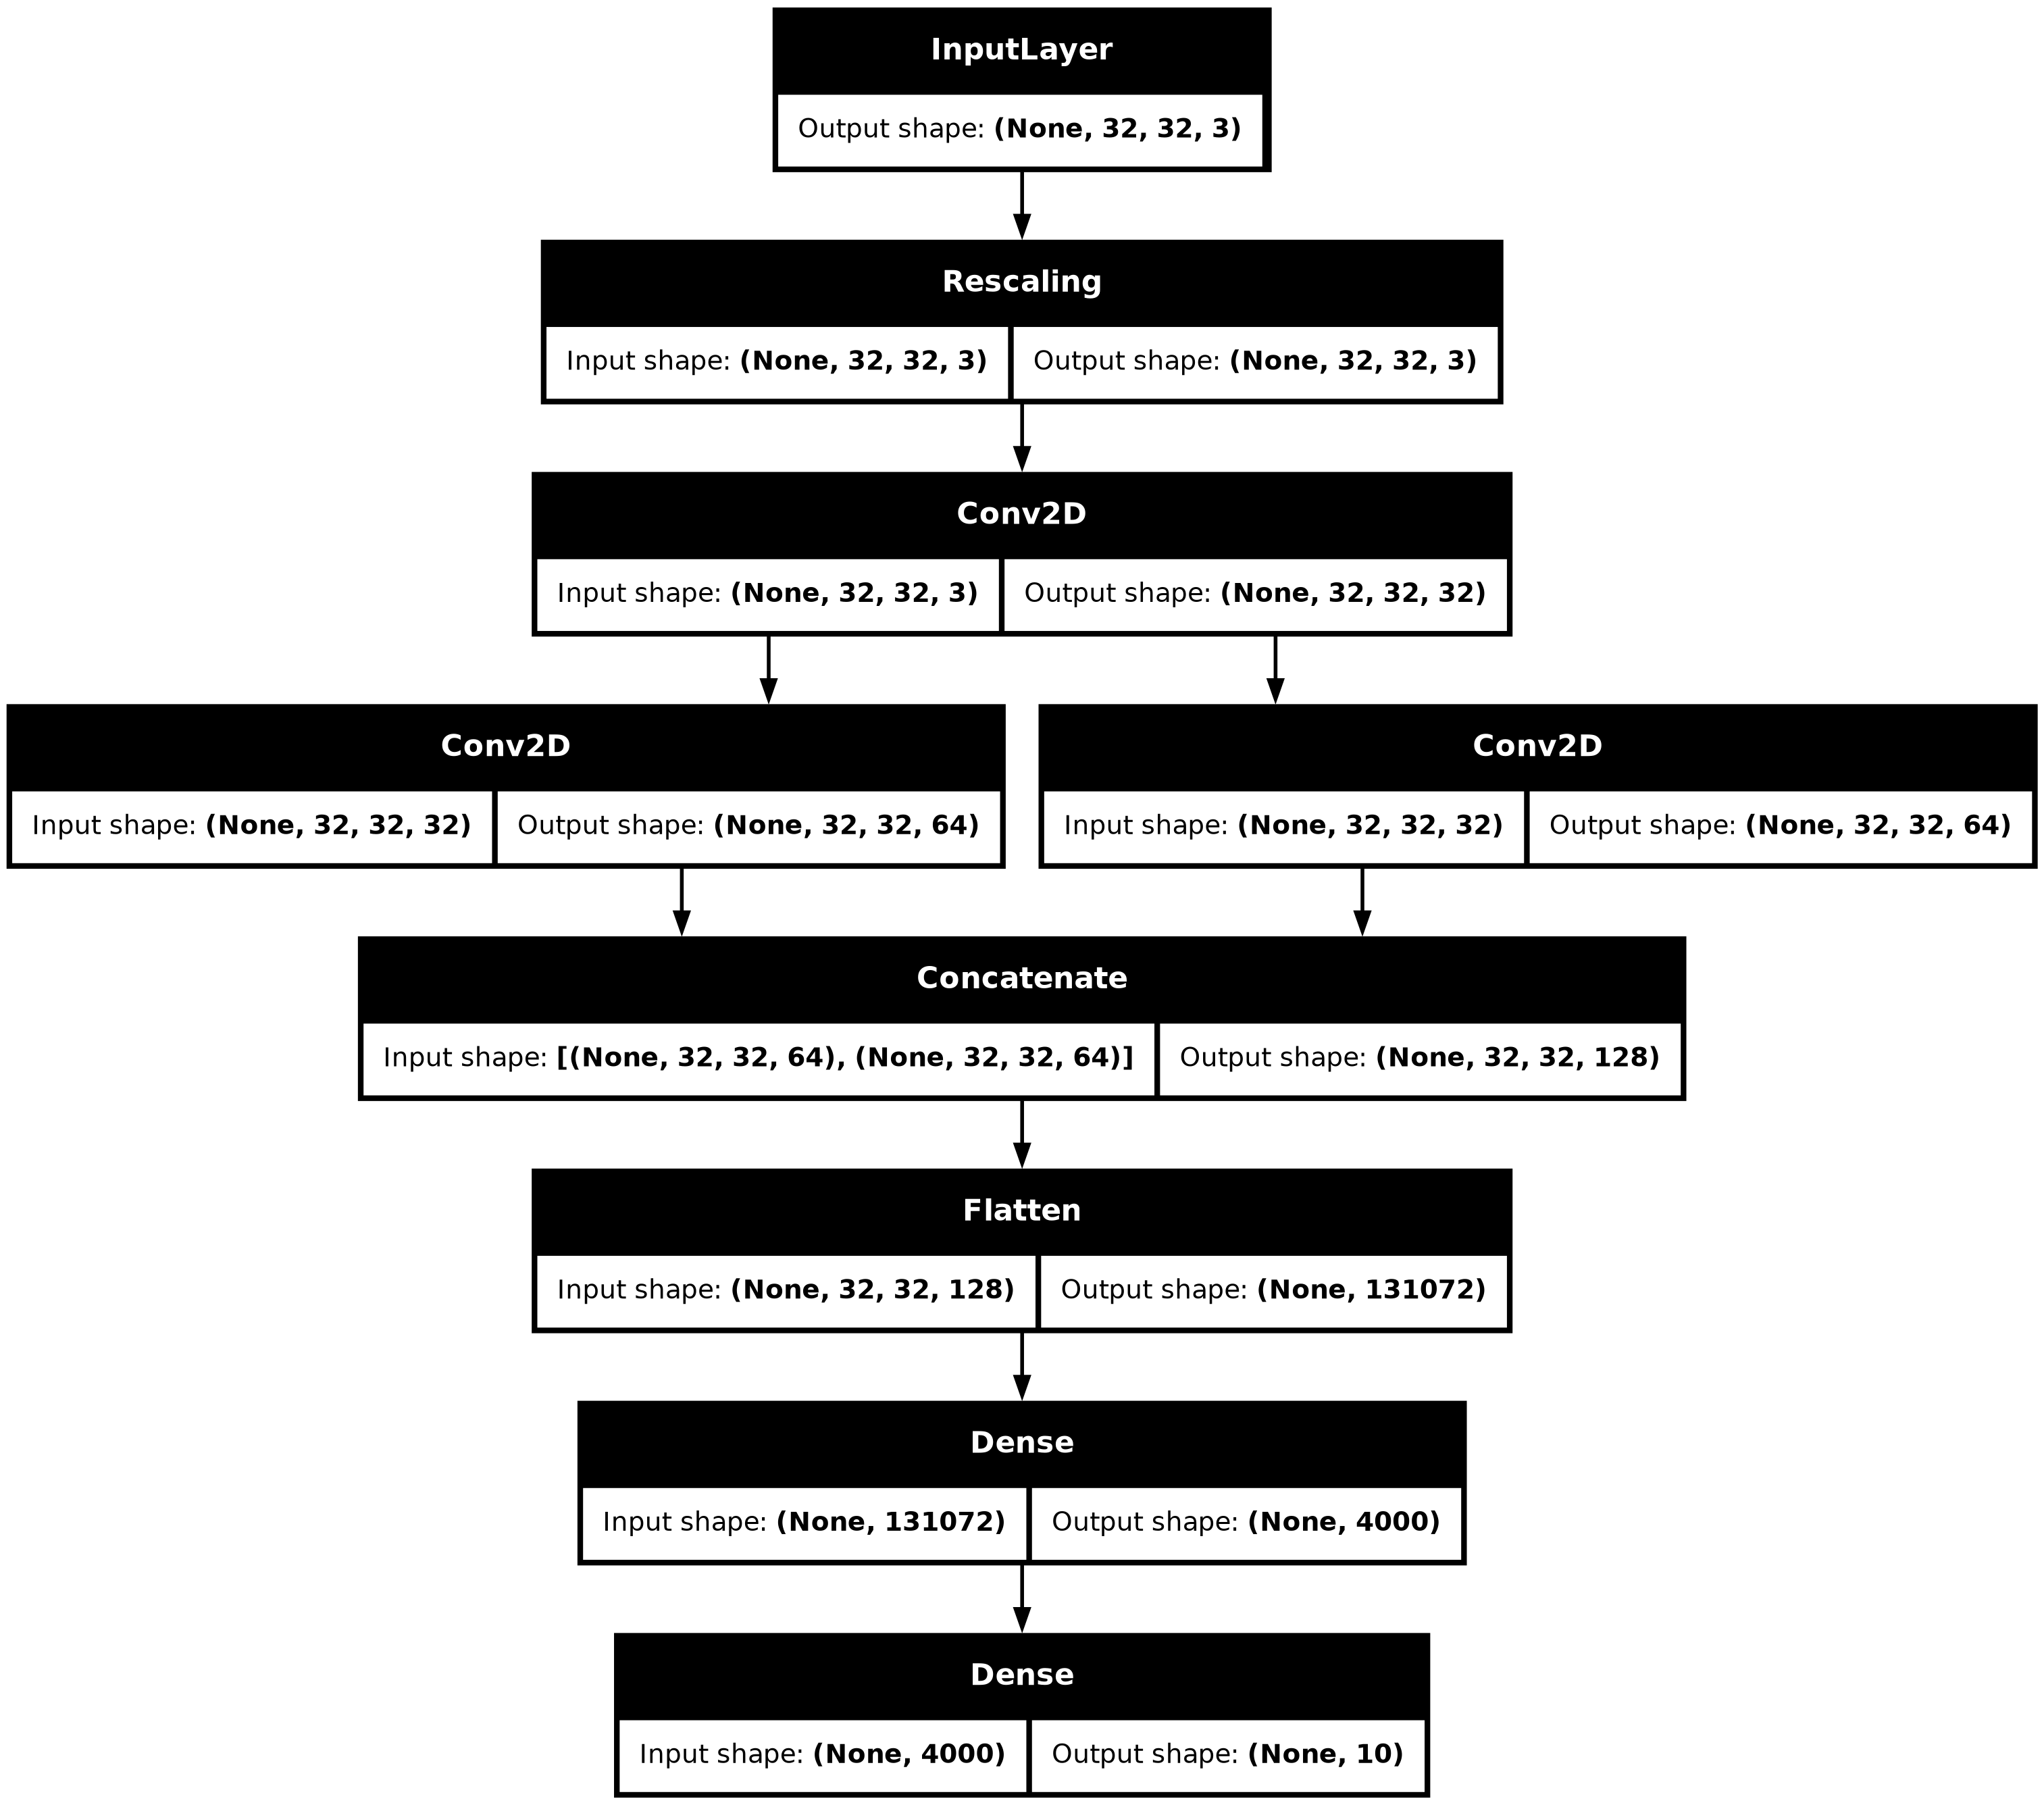

In [19]:
def block1(inputs, filter:int = 64):
    x = Convolution2D(filter, 3, 1, 'same', activation="relu")(inputs)
    x = ReLU()(x)
    x = Convolution2D(filter, 3, 1, 'same')(x)
    x = ReLU()(x)
    return  MaxPooling2D(2, 2)(x)



def block2(inputs, filter:int = 64):
    x = AveragePooling2D(2)(inputs)
    x= Convolution2D(filter, 3, 1, 'same')(x)
    return ReLU()(x)

def concat_block12(inputs):
    x_block1 = block1(inputs)    
    x_block2 =block2(inputs)
    return Concatenate()(x_block1,x_block2)

inputs = Input(x_train.shape[1:])

x = Rescaling(1.0 / 255)(inputs)

x = Convolution2D(32, 2, activation="relu", padding="same")(x)

left = Convolution2D(64, 5, activation="relu", padding="same")(x)
right = Convolution2D(64, 1, activation="relu", padding="same")(x)

x = Concatenate()([left, right])

x = Flatten()(x)
x = Dense(4000, activation="relu")(x)

out = Dense(10, activation="relu")(x)

cnn  = Model(inputs=inputs, outputs=out)

print(cnn.count_params)

plot_model(cnn, to_file="cnn_model.png", show_shapes=True, show_layer_names=True)


print("Model summary:")
cnn.summary()

plot_model(cnn, expand_nested=True, show_shapes=True)



# 5. Build a fresh model — critical experimental discipline

When you run `.fit()` again on the **same** model object, training continues from its existing weights.

Therefore a fair experiment should normally do this:

1. set/re-set the random seed;
2. build a **new model**;
3. train it;
4. record the result;
5. change one thing;
6. build another new model.

Your latest run begins around **70% training accuracy in epoch 1**, which is unusually high for what looks like a fresh CIFAR-10 run. That can happen if `.fit()` was rerun on an already-trained `cnn`.

The cell below makes the reset explicit.


In [10]:
# Reproducibility helper.
# This does not guarantee every GPU operation is perfectly identical,
# but it makes experiments much more comparable.
keras.utils.set_random_seed(42)

# BUILD A NEW MODEL before this experiment.
cnn = build_cnn_model(
    # Use Flip + RandomErasing.
    use_augmentation=True,

    # 30% Dropout.
    dropout_rate=0.30,
)

# Inspect architecture, output shapes and parameter counts.
cnn.summary()


I0000 00:00:1789552713.637543  135350 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789552713.685148  135350 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789552714.671663  135350 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing_1                │ (None, 32, 32, 3)      │             0 │
│ (RandomErasing)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,554 (2.55 MB)

 Trainable params: 668,554 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

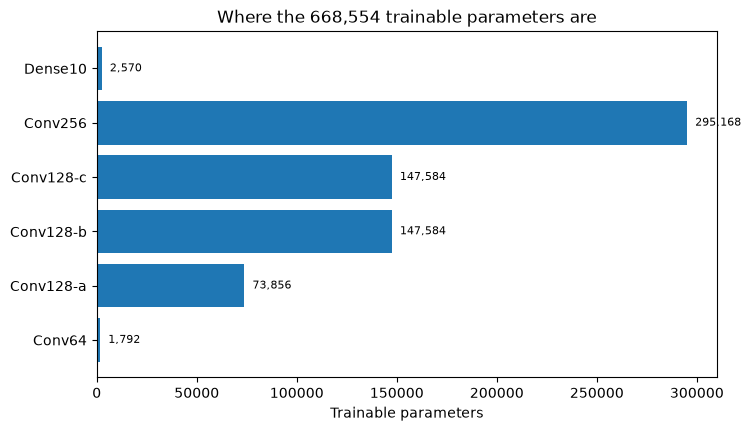

In [11]:
# Parameter counts from this exact architecture.
# Pooling, augmentation, GAP and Dropout have ZERO trainable parameters.

parameter_layers = [
    "Conv64",
    "Conv128-a",
    "Conv128-b",
    "Conv128-c",
    "Conv256",
    "Dense10",
]

parameter_counts = [
    1792,
    73856,
    147584,
    147584,
    295168,
    2570,
]

plt.figure(figsize=(8, 4.5))
plt.barh(parameter_layers, parameter_counts)
plt.xlabel("Trainable parameters")
plt.title("Where the 668,554 trainable parameters are")

for i, value in enumerate(parameter_counts):
    plt.text(
        value + 4000,
        i,
        f"{value:,}",
        va="center",
        fontsize=8,
    )

plt.show()

# KEY OBSERVATION:
# Most parameters are in the deeper convolution layers,
# especially Conv2D(256).
#
# GAP, pooling, Dropout and augmentation change behaviour
# without adding trainable weights.



## How parameter counts are calculated

For a convolution:

\[
\text{params}
=
(k_h \times k_w \times \text{input channels} + 1\text{ bias})
\times \text{number of filters}
\]

Example — first convolution:

\[
(3 \times 3 \times 3 + 1)\times64 = 1792
\]

For the last Dense layer:

\[
(256 + 1)\times10 = 2570
\]

The `+1` is the bias attached to each output unit/filter.

### Important distinction

**Output values are not the same thing as parameters.**

`MaxPooling2D` produces thousands of output values but has **0 learned parameters**.

`GlobalAveragePooling2D` also has **0 learned parameters**.

They transform information, but there are no weights to learn.


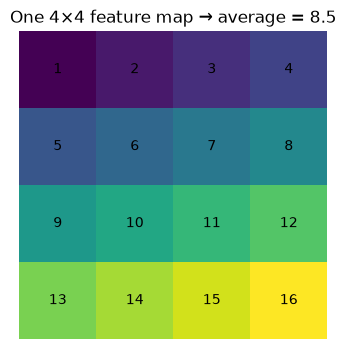

In [12]:
# Tiny conceptual example of GlobalAveragePooling.
# Imagine this is ONE of the 256 final feature maps.

feature_map_example = np.arange(1, 17).reshape(4, 4)

plt.figure(figsize=(5, 4))
plt.imshow(feature_map_example)

for (row, col), value in np.ndenumerate(feature_map_example):
    plt.text(
        col,
        row,
        str(value),
        ha="center",
        va="center",
    )

plt.title(
    f"One 4×4 feature map → average = {feature_map_example.mean():.1f}"
)
plt.axis("off")
plt.show()

# GAP does this independently for all 256 feature maps:
#
# 4×4×256
#    ↓
# 256 averages
#
# That is why GAP is such a strong compression.



# 6. Training callbacks — corrected

### Old setting

```python
min_delta=0.2
```

This was the main problem in the latest run.

### Recommended learning setting

```python
min_delta=0.001
```

Now a small but real reduction in validation loss can count as improvement.

`patience=7` means:

> if validation loss fails to improve sufficiently for 7 consecutive epochs, stop.

`restore_best_weights=True` means:

> when training stops, put the model weights back to the best validation point recognized by `EarlyStopping`.

We also make `mode="min"` explicit because for loss **lower is better**.


In [13]:
# Lower-case `callbacks` is conventional Python naming.
callbacks = [

    # Save the lowest-val_loss model to disk.
    ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",

        # For loss: lower is better.
        mode="min",

        # Save only when validation loss improves.
        save_best_only=True,

        verbose=1,
    ),

    # Stop when validation loss has genuinely stopped improving.
    EarlyStopping(
        monitor="val_loss",

        # Lower is better.
        mode="min",

        # Count changes smaller than 0.001 as effectively no improvement.
        # This is FAR more appropriate than the previous 0.2.
        min_delta=0.001,

        # Wait several epochs because validation naturally fluctuates.
        patience=7,

        # After stopping, return to the best recognized weights.
        restore_best_weights=True,

        verbose=1,
    ),
]



# 7. Diagnostic function — read the model like an analyst

The function below reports both:

- the **last logged epoch**, and
- the epoch with the **lowest validation loss**.

That distinction matters because the final epoch is not always the best model.


In [14]:
def plot_training_history(history, model_name="Model"):

    # One value for every completed epoch.
    train_acc = np.array(history.history["accuracy"])
    val_acc = np.array(history.history["val_accuracy"])
    train_loss = np.array(history.history["loss"])
    val_loss = np.array(history.history["val_loss"])

    # Lowest validation loss = our primary generalisation checkpoint.
    best_index = np.argmin(val_loss)

    # Human epoch numbering starts at 1, not 0.
    best_epoch = best_index + 1

    # Final logged gap.
    final_gap = train_acc[-1] - val_acc[-1]

    # Gap at the best validation-loss epoch.
    best_gap = train_acc[best_index] - val_acc[best_index]

    print("\n--- FINAL LOGGED EPOCH ---")
    print(f"Epoch:                       {len(train_acc)}")
    print(f"Training accuracy:           {train_acc[-1]:.4f}")
    print(f"Validation accuracy:         {val_acc[-1]:.4f}")
    print(f"Accuracy gap:                {final_gap:.4f} ({final_gap*100:.2f} pp)")
    print(f"Training loss:               {train_loss[-1]:.4f}")
    print(f"Validation loss:             {val_loss[-1]:.4f}")

    print("\n--- BEST VALIDATION-LOSS EPOCH ---")
    print(f"Epoch:                       {best_epoch}")
    print(f"Training accuracy:           {train_acc[best_index]:.4f}")
    print(f"Validation accuracy:         {val_acc[best_index]:.4f}")
    print(f"Accuracy gap:                {best_gap:.4f} ({best_gap*100:.2f} pp)")
    print(f"Training loss:               {train_loss[best_index]:.4f}")
    print(f"Validation loss:             {val_loss[best_index]:.4f}")


    # ACCURACY GRAPH
    plt.figure(figsize=(8, 4))
    plt.plot(train_acc, label="Training")
    plt.plot(val_acc, label="Validation")
    plt.axvline(
        best_index,
        linestyle="--",
        label=f"Best val_loss epoch: {best_epoch}",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} — Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


    # LOSS GRAPH
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label="Training")
    plt.plot(val_loss, label="Validation")
    plt.axvline(
        best_index,
        linestyle="--",
        label=f"Best val_loss epoch: {best_epoch}",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} — Loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


    # GENERALISATION GAP GRAPH
    gap_per_epoch = train_acc - val_acc

    plt.figure(figsize=(8, 4))
    plt.plot(gap_per_epoch, marker="o")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Train accuracy - Validation accuracy")
    plt.title(f"{model_name} — Generalisation gap")
    plt.grid(alpha=0.25)
    plt.show()



# 8. Train the corrected experiment

### Parameters used

- augmentation: **Flip + RandomErasing**
- filters: **64 → 128 → 128 → 128 → 256**
- pooling: **three 2×2 MaxPooling stages**
- classifier compression: **GlobalAveragePooling**
- dropout: **0.30**
- optimizer: **Adam default**
- batch size: **512**
- maximum epochs: **50**
- EarlyStopping: **min_delta=0.001, patience=7**

This is now a clearly specified experiment.  
If we change something later, we can say exactly what changed.


Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2247 - loss: 2.0402
Epoch 1: val_loss improved from None to 1.80155, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.2247 - loss: 2.0402 - val_accuracy: 0.3253 - val_loss: 1.8016
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3480 - loss: 1.7342
Epoch 2: val_loss improved from 1.80155 to 1.65875, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.3480 - loss: 1.7342 - val_accuracy: 0.3806 - val_loss: 1.6588
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4158 - loss: 1.5653
Epoch 3: val_loss improved from 1.65875 to 1.44830, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.4158 - loss: 1.5653 - val_accuracy: 0.4744 - val_lo

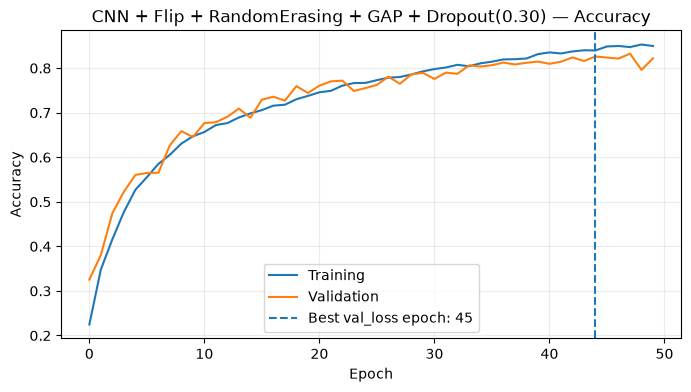

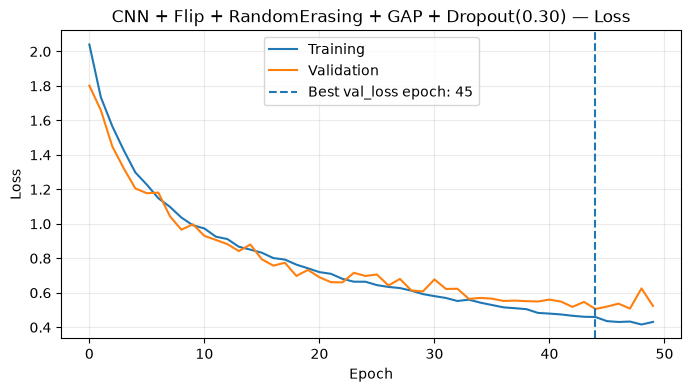

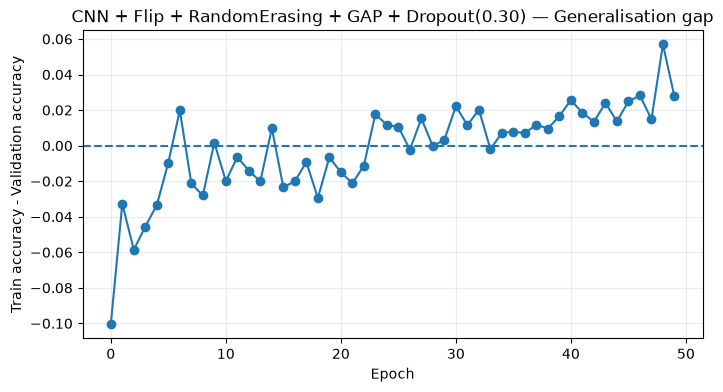

In [15]:
# Train the freshly built model.
cnn_history = cnn.fit(
    # Training images and labels.
    x_train,
    y_train,

    # 40,000 / 512 ≈ 79 batches per epoch.
    batch_size=512,

    # Maximum only.
    # EarlyStopping may stop before epoch 50.
    epochs=50,

    # Validation is used for monitoring,
    # not for updating model weights.
    validation_data=(x_val, y_val),

    # ACTIVATE the callbacks.
    callbacks=callbacks,

    # Show one progress report per epoch.
    verbose=1,
)

# Analyse the logged history.
plot_training_history(
    cnn_history,
    "CNN + Flip + RandomErasing + GAP + Dropout(0.30)",
)



# 9. Verify what “best model” means

After training, verify both:

1. the model currently in memory after `EarlyStopping` restored weights;
2. the model saved by `ModelCheckpoint`.

With the corrected callback settings, these should be close. If they differ materially, investigate why.


In [16]:
# Evaluate the model currently in memory.
restored_val_loss, restored_val_acc = cnn.evaluate(
    x_val,
    y_val,
    verbose=0,
)

print("Restored in-memory model")
print(f"Validation loss:     {restored_val_loss:.4f}")
print(f"Validation accuracy: {restored_val_acc:.4f}")


# Load the best checkpoint saved to disk.
checkpoint_model = keras.models.load_model("best_model.keras")

checkpoint_val_loss, checkpoint_val_acc = checkpoint_model.evaluate(
    x_val,
    y_val,
    verbose=0,
)

print("\nSaved checkpoint model")
print(f"Validation loss:     {checkpoint_val_loss:.4f}")
print(f"Validation accuracy: {checkpoint_val_acc:.4f}")


Restored in-memory model
Validation loss:     0.5059
Validation accuracy: 0.8261

Saved checkpoint model
Validation loss:     0.5059
Validation accuracy: 0.8261



# 10. How to decide the NEXT change

Use the result, not intuition alone.

| Result pattern | Diagnosis | What to experiment with next |
|---|---|---|
| Train low, validation low | underfitting / insufficient learning | more epochs, learning rate, more capacity, weaker regularisation |
| Train high, validation much lower | overfitting | stronger augmentation, Dropout, L2, GAP, EarlyStopping |
| Train and validation both good and close | healthy generalisation | stop adding regularisation automatically |
| Validation loss improves until the final epoch | probably not finished | allow more epochs with EarlyStopping |
| Validation loss bottoms early then rises | overfitting / training too long | EarlyStopping; possibly more regularisation |
| Bigger model raises train but not validation | diminishing returns | stop enlarging; change representation/regularisation |
| Accuracy around 10%, loss around 2.3026 | essentially random 10-class prediction | inspect pipeline/configuration before tuning |



# 11. Controlled experiment ladder

Do these **one at a time**.

### Experiment A — corrected callbacks only
Keep the current model exactly as written.

Question:

> Does corrected EarlyStopping allow the current architecture to reach its natural validation optimum?

### Experiment B — RandomErasing contribution
Remove only `RandomErasing`.

Keep:

- Flip
- GAP
- Dropout 0.30
- all filters
- batch 512
- Adam

Question:

> Is RandomErasing helping validation performance, or merely making training harder?

### Experiment C — Dropout contribution
Keep augmentation and GAP, but set:

```python
dropout_rate=0.0
```

Question:

> Is Dropout still necessary when GAP already strongly reduces classifier capacity?

### Experiment D — GAP versus Flatten
Replace:

```python
GlobalAveragePooling2D()
```

with:

```python
Flatten()
Dense(128, activation="relu")
```

Question:

> How much of the reduced overfitting comes specifically from GAP?

### Experiment E — batch size
Keep the architecture unchanged and compare:

```python
batch_size=512
```

with:

```python
batch_size=256
```

Question:

> Do more frequent weight updates improve convergence or generalisation?


In [17]:
# Small manual experiment log.
# Add one dictionary after each completed controlled experiment.

experiment_log = [
    {
        "name": "Regularisation-4 original recorded run",
        "augmentation": "Flip + RandomErasing",
        "dropout": 0.30,
        "pooling_head": "GAP",
        "batch_size": 512,
        "epochs_completed": 11,
        "best_val_loss_epoch": 10,
        "final_train_acc": 0.7636,
        "final_val_acc": 0.7573,
        "best_val_loss": 0.6932,
        "important_note": "Old EarlyStopping min_delta=0.2 restored epoch 1",
    },
]

# Print the log in a readable form.
for experiment in experiment_log:
    print("\n", experiment["name"])
    for key, value in experiment.items():
        if key != "name":
            print(f"  {key}: {value}")



 Regularisation-4 original recorded run
  augmentation: Flip + RandomErasing
  dropout: 0.3
  pooling_head: GAP
  batch_size: 512
  epochs_completed: 11
  best_val_loss_epoch: 10
  final_train_acc: 0.7636
  final_val_acc: 0.7573
  best_val_loss: 0.6932
  important_note: Old EarlyStopping min_delta=0.2 restored epoch 1



# 12. Test set — final exam, not a tuning dashboard

Do **not** evaluate the test set after every small experiment.

Use validation to choose among experiments.  
Use test when you have selected a serious final candidate.

Then:

```python
test_loss, test_accuracy = cnn.evaluate(x_test, y_test)
```

If you repeatedly choose parameters based on test performance, the test set gradually becomes another validation set and stops being an independent examination.


In [18]:
# FINAL evaluation — run only when you have selected the model candidate.
#
# Uncomment when appropriate.

# test_loss, test_accuracy = cnn.evaluate(
#     x_test,
#     y_test,
#     verbose=0,
# )
#
# print(f"Test loss:     {test_loss:.4f}")
# print(f"Test accuracy: {test_accuracy:.4f}")



# 13. Your 60-second diagnosis checklist

Before changing any model parameter, answer these in order:

1. **Can the model fit training data?**  
   Look at training accuracy and training loss.

2. **Does it generalise?**  
   Look at validation accuracy and validation loss.

3. **How large is the train–validation gap?**  
   A widening gap can indicate overfitting.

4. **Where is the lowest validation loss?**  
   The final epoch is not automatically the best epoch.

5. **Did callbacks behave as intended?**  
   Check `monitor`, `mode`, `min_delta`, `patience`, and `restore_best_weights`.

6. **Was this really a fresh experiment?**  
   Rebuild the model before `.fit()` if you want a clean comparison.

7. **Did I change only one main thing?**  
   If not, interpretation becomes weak.

8. **What exact question does my next experiment answer?**  
   If you cannot state the question in one sentence, the experiment is probably too broad.
